In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import re

# Configurations
sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
pio.renderers.default = "notebook"

In [2]:
df_usa = pd.read_csv("US_Accidents_March23.csv")

In [3]:
print(df_usa.columns)
print(df_usa["State"].value_counts().head())

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')
State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
Name: count, dtype: int64


In [4]:
#Extracting California into a new variable "df"
# df_usa[df_usa["State"] == "CA"].to_csv("CA.csv", index=False)
df = df_usa[df_usa["State"] == "CA"].copy()
del df_usa

Initial Exploration of the Subset
Loading the filtered California dataset to check its structure, data types, and missing values.

In [5]:
print(df.head(5))
print(df.info())
display(df.describe().T)

        ID   Source  Severity           Start_Time             End_Time  \
728  A-729  Source2         3  2016-06-21 10:34:40  2016-06-21 11:04:40   
729  A-730  Source2         3  2016-06-21 10:30:16  2016-06-21 11:16:39   
730  A-731  Source2         2  2016-06-21 10:49:14  2016-06-21 11:19:14   
731  A-732  Source2         3  2016-06-21 10:41:42  2016-06-21 11:11:42   
732  A-733  Source2         2  2016-06-21 10:16:26  2016-06-21 11:04:16   

     Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  \
728      38.09    -122.23      NaN      NaN          0.00   
729      37.63    -122.08      NaN      NaN          0.00   
730      37.90    -122.07      NaN      NaN          0.00   
731      37.33    -122.03      NaN      NaN          0.00   
732      37.25    -121.91      NaN      NaN          0.00   

                                           Description               Street  \
728  Right hand shoulder blocked due to accident on...          Magazine St   
729  Accident on I-880 N

,count,mean,std,min,25%,50%,75%,max
Severity,1741433.00,2.17,0.41,1.00,2.00,2.00,2.00,4.00
Start_Lat,1741433.00,35.63,2.09,32.54,33.98,34.24,37.70,42.01
Start_Lng,1741433.00,-119.50,1.94,-124.37,-121.52,-118.44,-117.92,-114.14
End_Lat,1104102.00,35.65,2.13,32.54,33.98,34.26,37.70,42.14
End_Lng,1104102.00,-119.46,1.92,-124.40,-121.44,-118.45,-117.89,-114.14
Distance(mi),1741433.00,0.48,1.35,0.00,0.00,0.02,0.43,227.21
Temperature(F),1695464.00,63.90,13.59,-29.90,55.00,63.00,72.00,207.00
Wind_Chill(F),1230468.00,62.76,14.60,-28.00,54.00,62.00,72.00,207.00
Humidity(%),1693092.00,58.71,24.21,1.00,40.00,61.00,78.00,100.00
Pressure(in),1704307.00,29.63,0.78,0.30,29.62,29.86,29.99,58.39


,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,1741433.00,1695464.00,1230468.00,1693092.00,1704307.00,1701308.00,1578542.00,1175229.00
mean,0.48,63.90,62.76,58.71,29.63,9.09,6.55,0.00
std,1.35,13.59,14.60,24.21,0.78,2.52,5.70,0.04
min,0.00,-29.90,-28.00,1.00,0.30,0.00,0.00,0.00
25%,0.00,55.00,54.00,40.00,29.62,10.00,3.00,0.00
50%,0.02,63.00,62.00,61.00,29.86,10.00,6.00,0.00
75%,0.43,72.00,72.00,78.00,29.99,10.00,9.20,0.00
max,227.21,207.00,207.00,100.00,58.39,140.00,1087.00,24.00


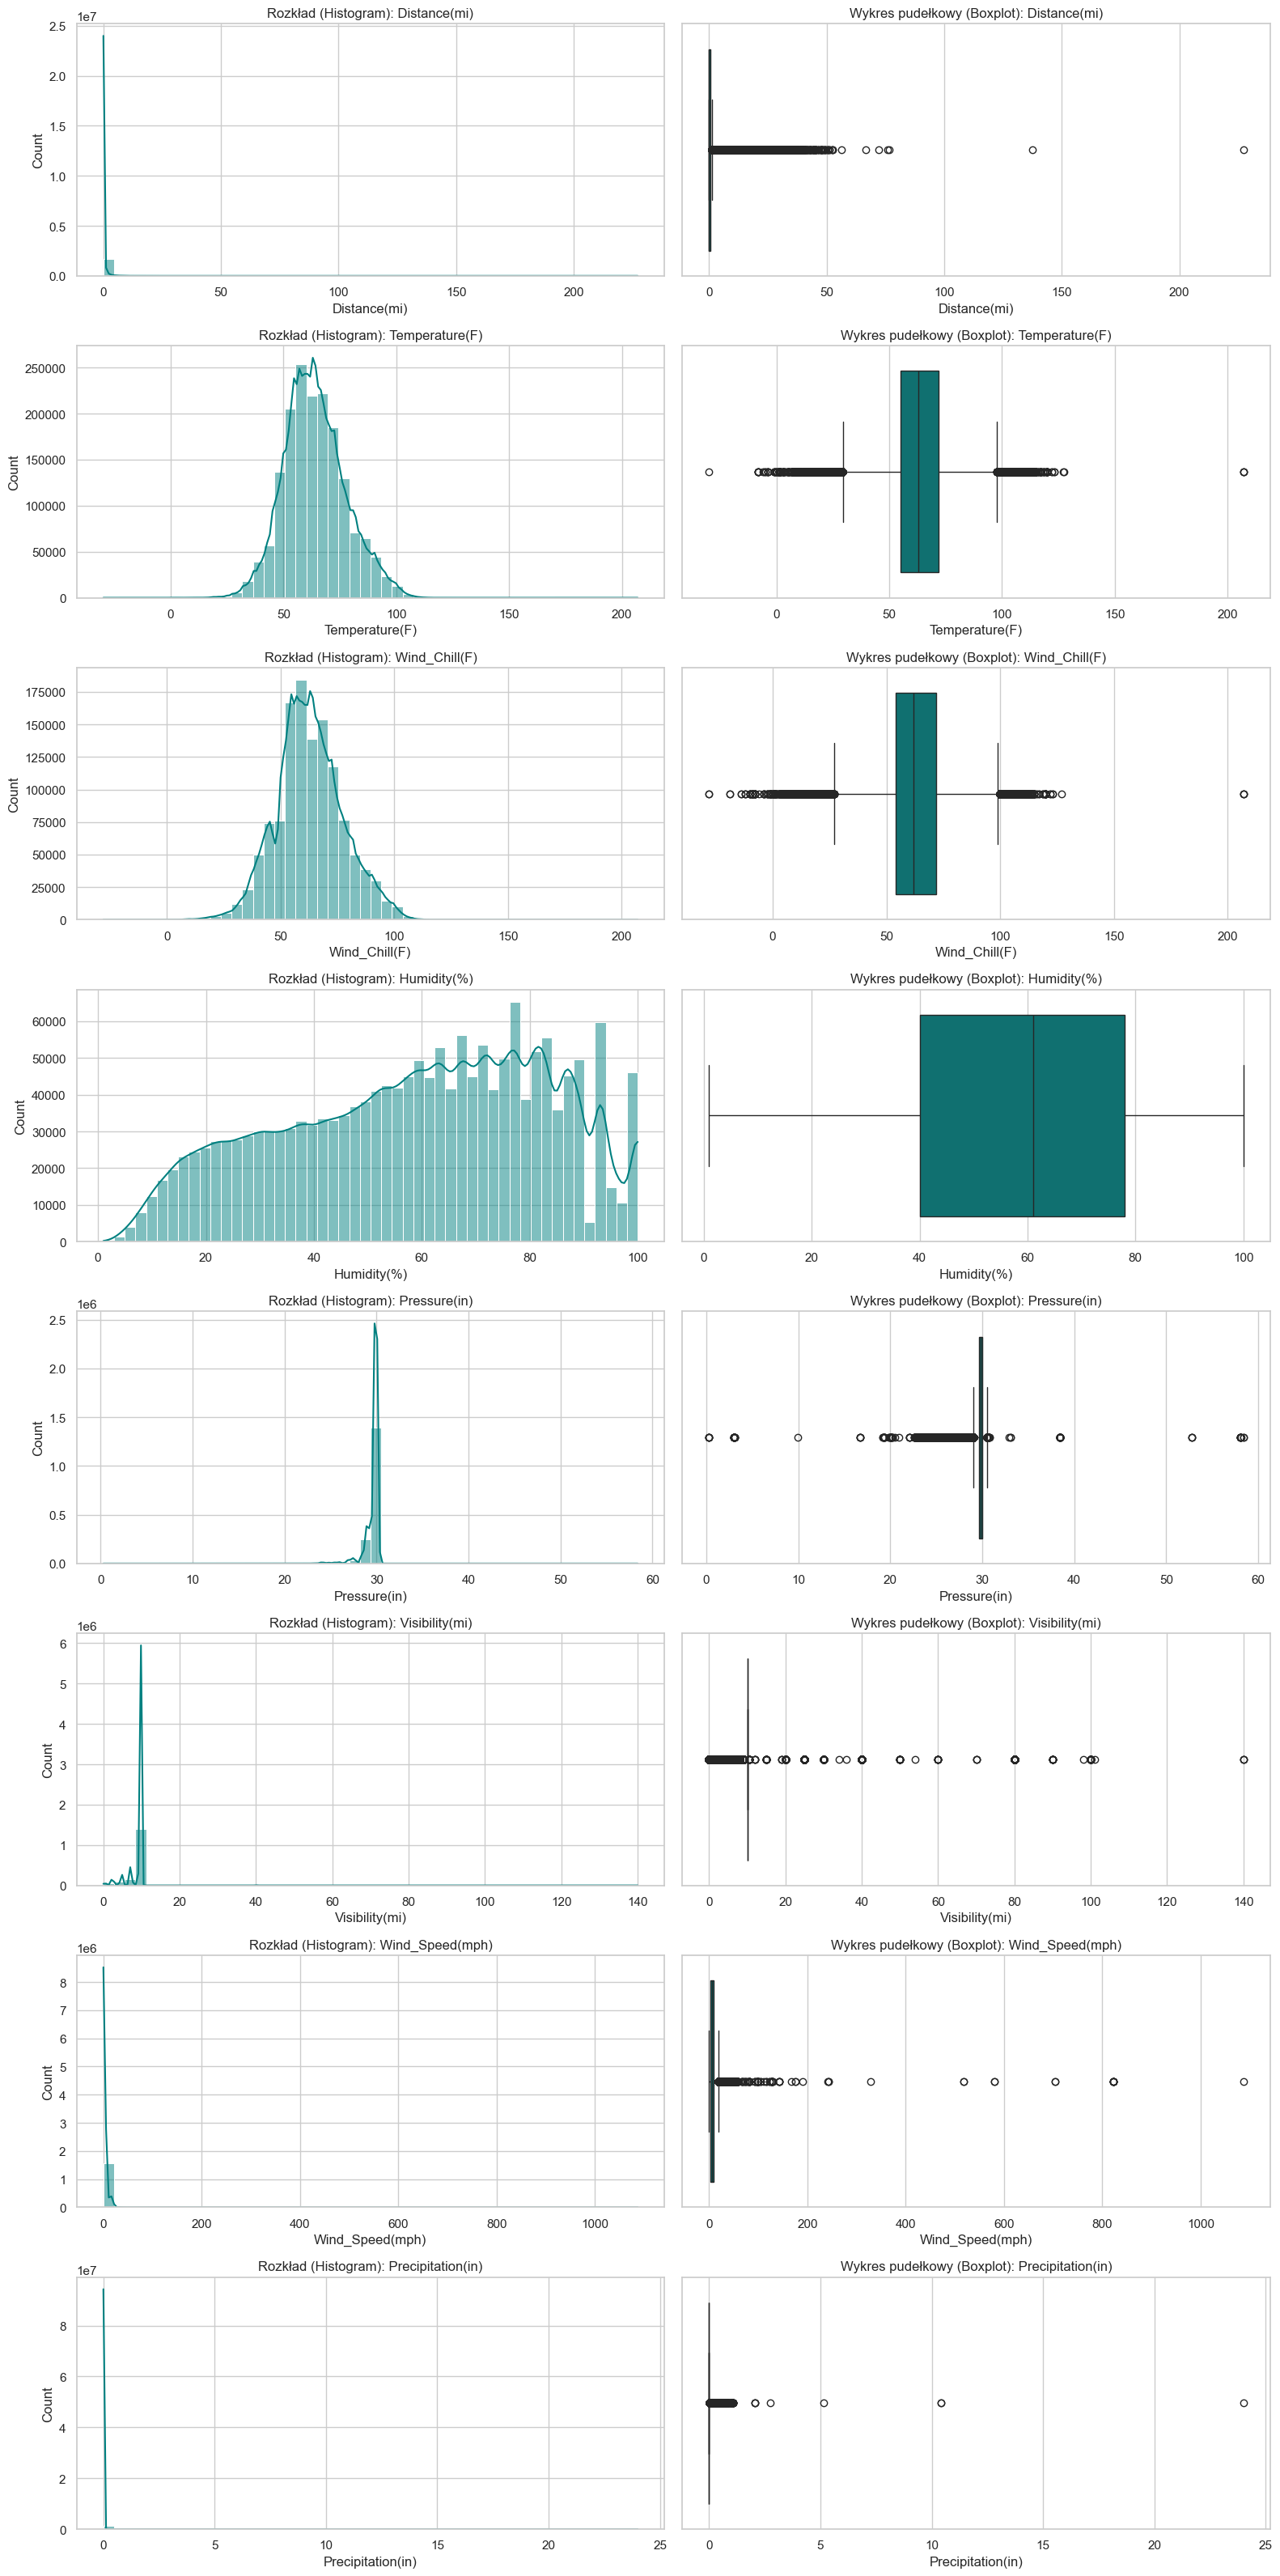

In [6]:
cols_to_analyze = [
    'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]
display(df[cols_to_analyze].describe())

fig, axes = plt.subplots(len(cols_to_analyze), 2, figsize=(16, 4 * len(cols_to_analyze)))

for i, col in enumerate(cols_to_analyze):
    # Histogram 
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Rozkład (Histogram): {col}')
    
    # Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color='teal')
    axes[i, 1].set_title(f'Wykres pudełkowy (Boxplot): {col}')

plt.tight_layout()
plt.show()

In [7]:
# Dictionary definition of safe boundaries
clipping_rules = {
    'Distance(mi)': (0, 15),
    'Temperature(F)': (-20, 120),
    'Wind_Chill(F)': (-30, 120),
    'Humidity(%)': (0, 100),
    'Pressure(in)': (28, 31),
    'Visibility(mi)': (0, 10),
    'Wind_Speed(mph)': (0, 100),
    'Precipitation(in)': (0, 2)
}

# Apply trim in loop
for col, limits in clipping_rules.items():
    if col in df.columns:
        df[col] = df[col].clip(lower=limits[0], upper=limits[1])
        
# Check the effects
print("Statystyki po przycięciu:")
display(df[list(clipping_rules.keys())].describe())

Statystyki po przycięciu:


,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,1741433.00,1695464.00,1230468.00,1693092.00,1704307.00,1701308.00,1578542.00,1175229.00
mean,0.48,63.90,62.76,58.71,29.69,9.06,6.54,0.00
std,1.22,13.59,14.59,24.21,0.51,2.17,5.22,0.03
min,0.00,-20.00,-28.00,1.00,28.00,0.00,0.00,0.00
25%,0.00,55.00,54.00,40.00,29.62,10.00,3.00,0.00
50%,0.02,63.00,62.00,61.00,29.86,10.00,6.00,0.00
75%,0.43,72.00,72.00,78.00,29.99,10.00,9.20,0.00
max,15.00,120.00,120.00,100.00,31.00,10.00,100.00,2.00


In [8]:
# Count and display missing values per column
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

End_Lng                  637331
End_Lat                  637331
Precipitation(in)        566204
Wind_Chill(F)            510965
Wind_Speed(mph)          162891
Humidity(%)               48341
Wind_Direction            46189
Temperature(F)            45969
Visibility(mi)            40125
Weather_Condition         39778
Pressure(in)              37126
Weather_Timestamp         32805
Street                     2442
Airport_Code               2116
Sunrise_Sunset             1343
Civil_Twilight             1343
Nautical_Twilight          1343
Astronomical_Twilight      1343
Timezone                    597
Zipcode                     597
City                         11
Description                   3
dtype: int64

In [9]:
# Drop columns with a high percentage of missing values
columns_to_drop = ['End_Lat', 'End_Lng', 'Number', 'Wind_Chill(F)', 'Precipitation(in)']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Drop rows with minor missing values in specific columns
cols_with_minor_nans = ['City', 'Zipcode', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Airport_Code', 'Weather_Timestamp', 'Street', 'Description']
cols_to_dropna = [col for col in cols_with_minor_nans if col in df.columns]
df.dropna(subset=cols_to_dropna, inplace=True)

# Impute missing values for numerical features using the median
numeric_cols_to_impute = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']
for col in numeric_cols_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Impute missing values for categorical features using the mode
categorical_cols_to_impute = ['Wind_Direction', 'Weather_Condition']
for col in categorical_cols_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])


df.isnull().sum().sum()  #check

np.int64(0)

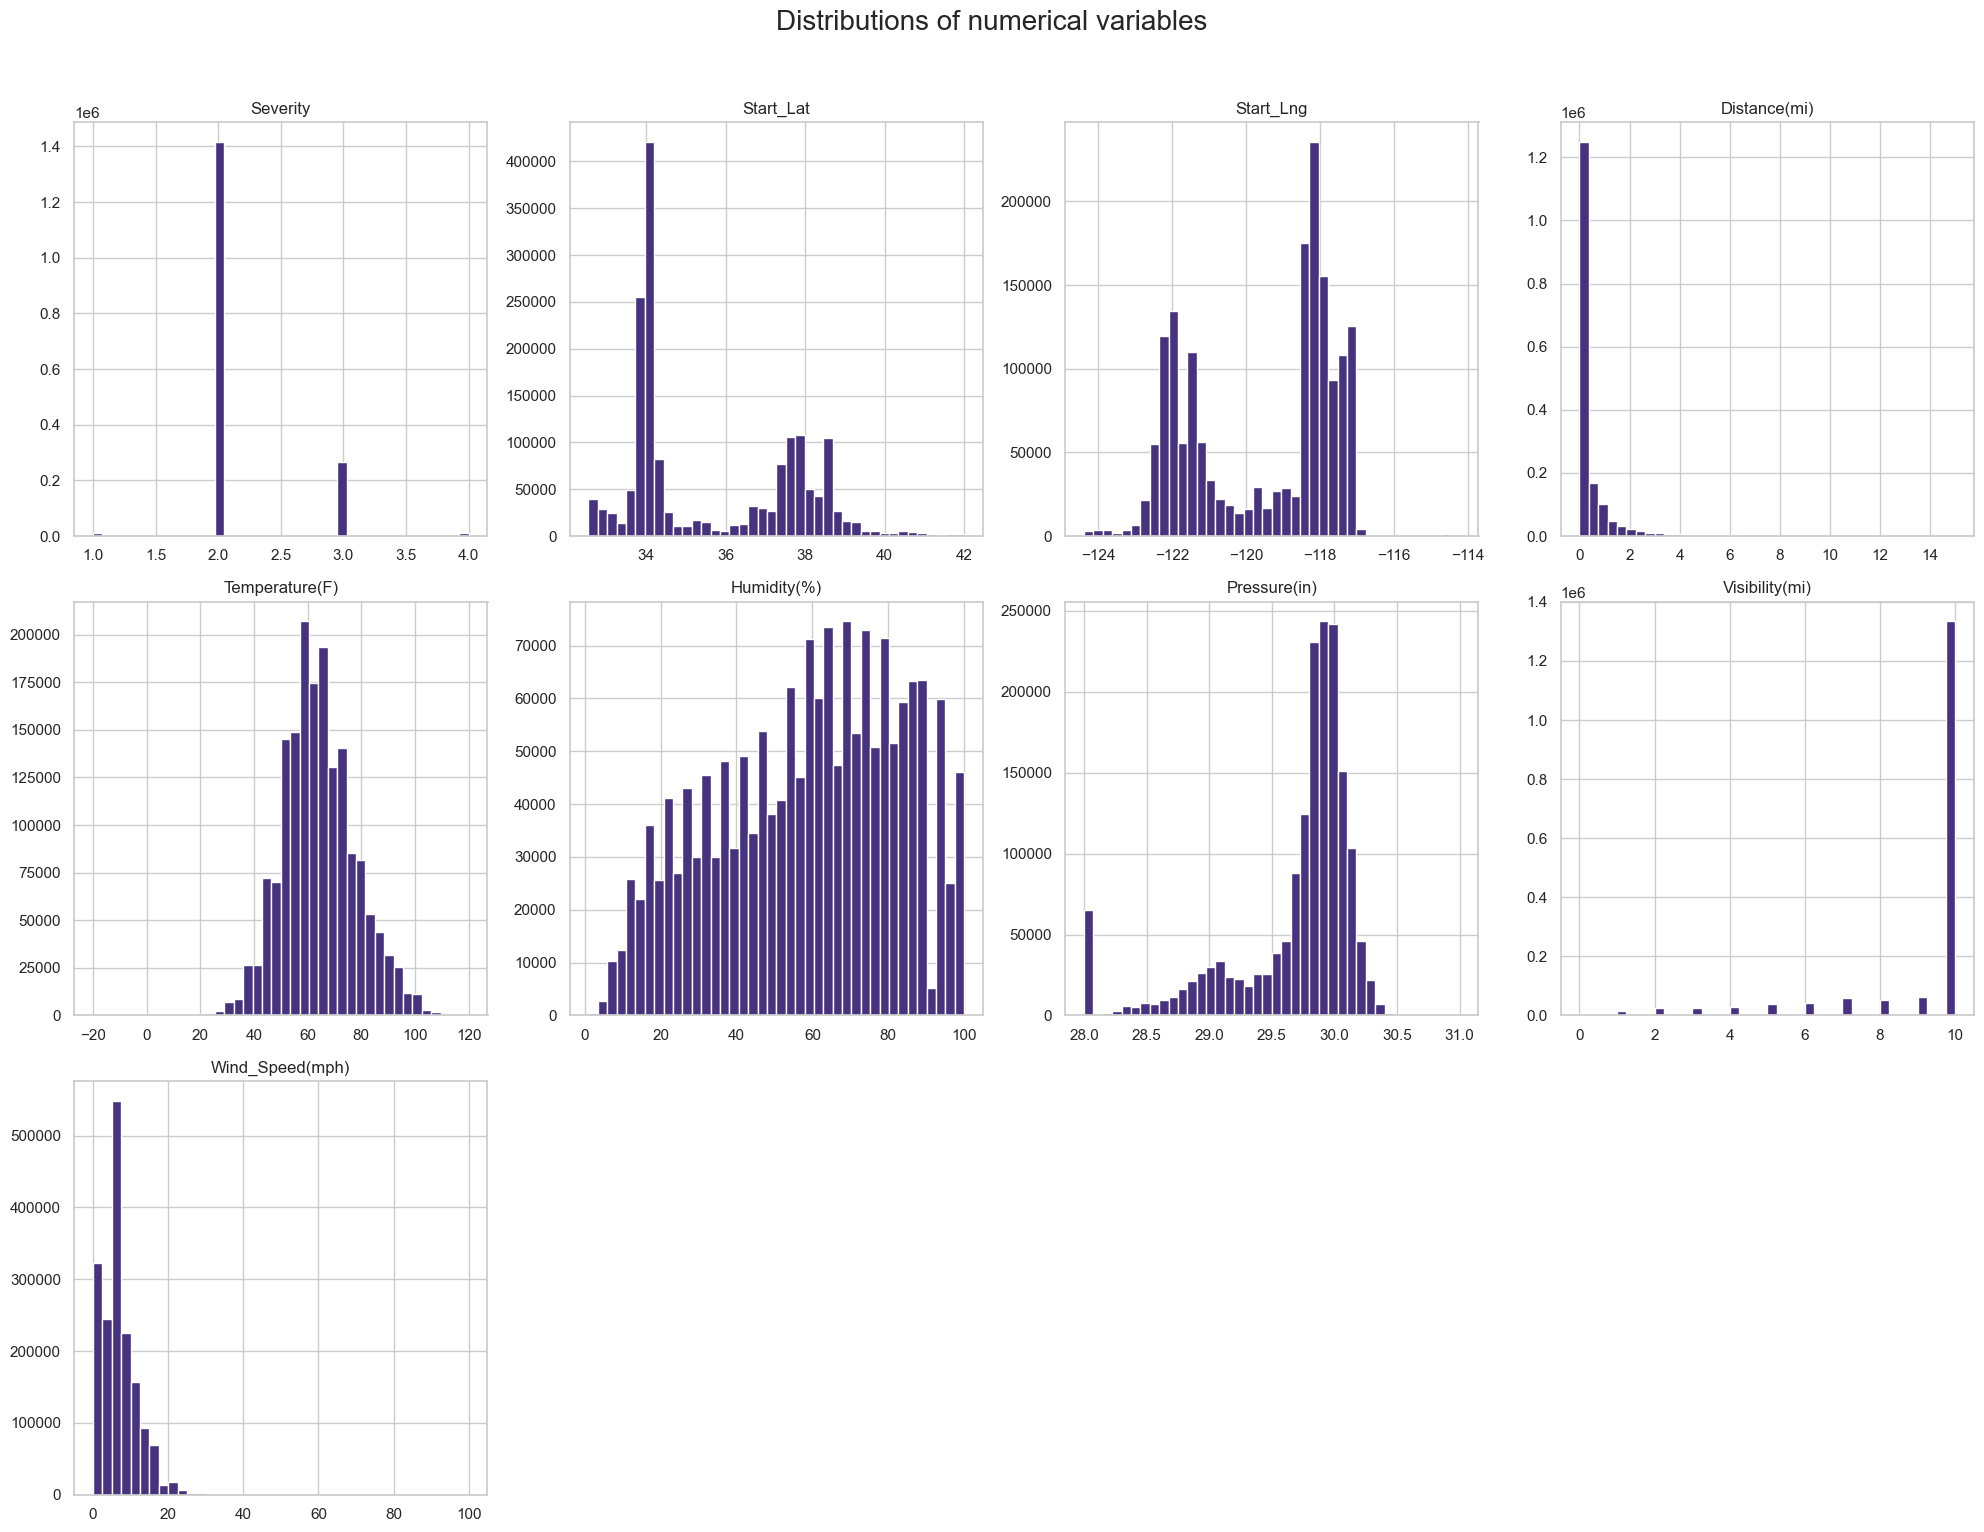

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(bins=40, figsize=(20, 15), layout=(-1, 4))

plt.suptitle('Distributions of numerical variables', y=1.02, fontsize=20)
plt.tight_layout()
plt.show()

In [11]:
df.drop(columns=["Description", "ID", "Source","State", "Country"], inplace=True)
print(df.shape)

(1705412, 37)


Temporal Feature Engineering
Converting string timestamps to datetime objects, extracting time components, and calculating the total duration of each accident.

In [12]:
# Convert to datetime objects
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed', errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], format='mixed', errors='coerce')

# Drop rows where datetime parsing failed
df.dropna(subset=['Start_Time', 'End_Time'], inplace=True)

# Extract time components
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek
df['Month'] = df['Start_Time'].dt.month
df['Year'] = df['Start_Time'].dt.year

# Calculate accident duration in minutes
df['Duration(min)'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
display(df['Duration(min)'].describe())

count   1705412.00
mean        119.74
std        1408.27
min           3.00
25%          33.17
50%          76.25
75%         130.87
max      631316.73
Name: Duration(min), dtype: float64

 Outlier Treatment and Spatial Features
Clipping extreme values to reduce the impact of outliers and identifying point events based on distance.

In [13]:
# Create a boolean feature for accidents with near-zero impact distance
df['is_point_event'] = df['Distance(mi)'] <= 0.02
display(df['is_point_event'].value_counts())

is_point_event
False    860694
True     844718
Name: count, dtype: int64

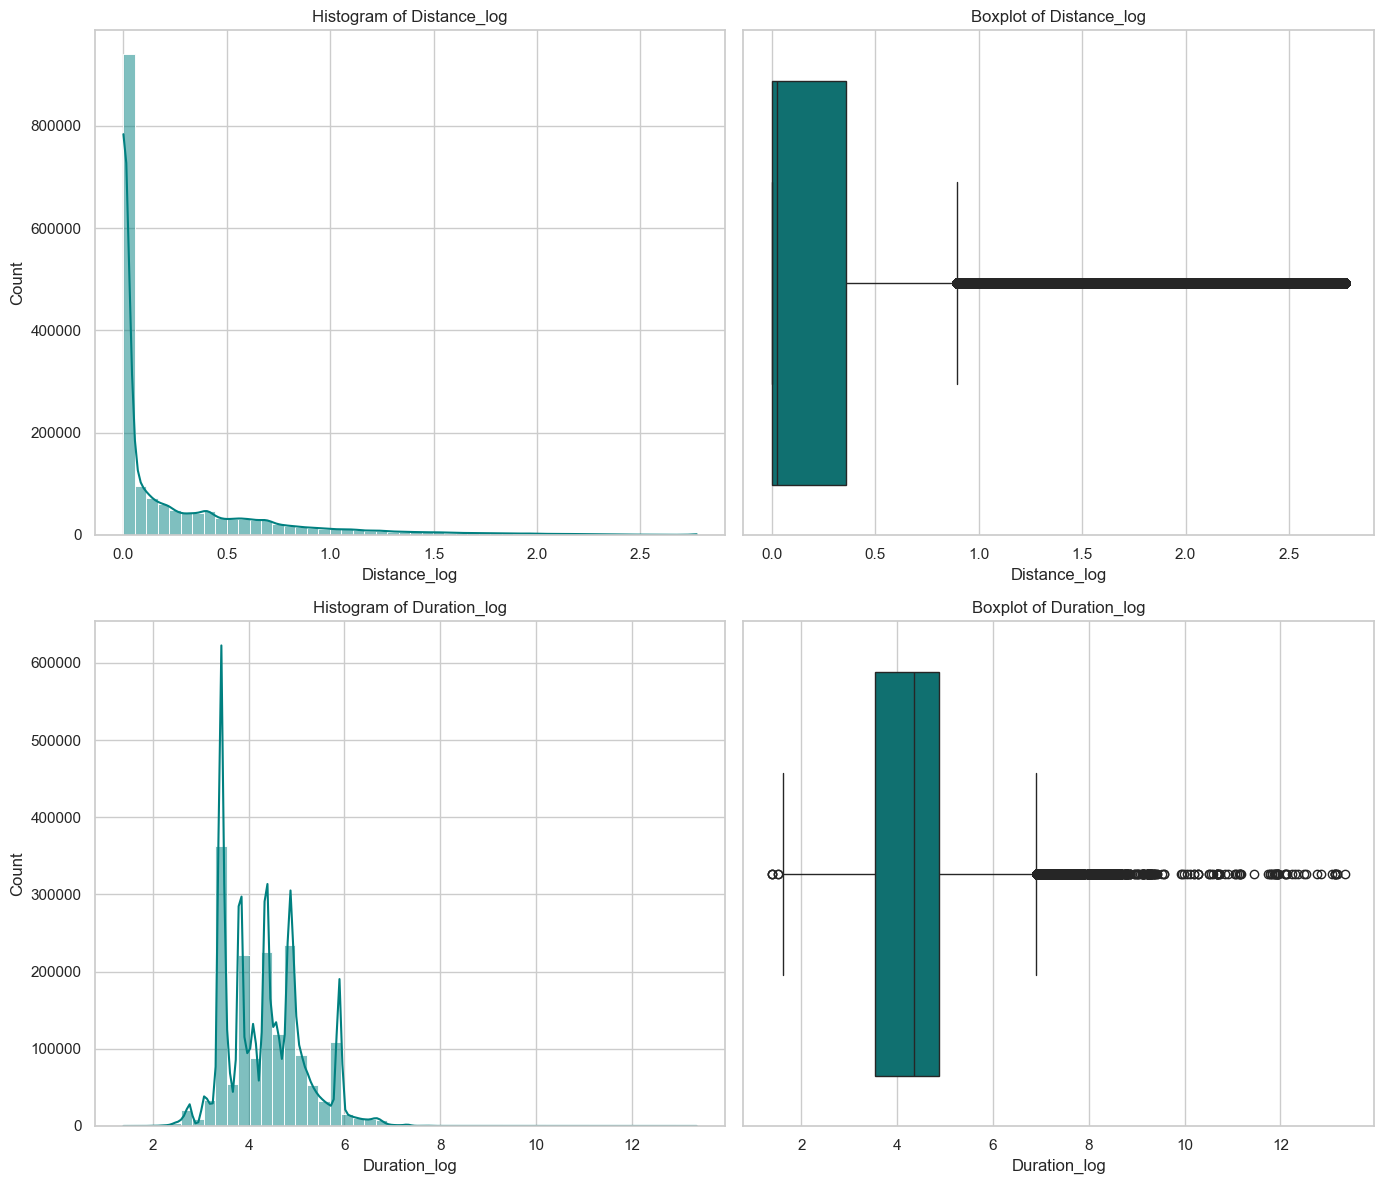

In [15]:
# Logarithmic transformation for skewed variables
df['Distance_log'] = np.log1p(df['Distance(mi)'])
df['Duration_log'] = np.log1p(df['Duration(min)'])

features_to_plot = ['Distance_log', 'Duration_log']

# Generate Histograms and Boxplots
fig, axes = plt.subplots(len(features_to_plot), 2, figsize=(14, 6 * len(features_to_plot)))
for i, feature in enumerate(features_to_plot):
    # Histogram
    sns.histplot(df[feature], bins=50, kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Histogram of {feature}')
    
    # Boxplot
    sns.boxplot(x=df[feature], ax=axes[i, 1], color='teal')
    axes[i, 1].set_title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()

df.drop(columns=['Distance(mi)', 'Duration(min)'], inplace=True, errors='ignore')

Weather Condition Aggregation
Grouping granular weather descriptions into broader, standardized categories for modeling.

In [14]:
print(df['Weather_Condition'].unique())
print(df['Weather_Condition'].value_counts())

['Clear' 'Partly Cloudy' 'Haze' 'Mostly Cloudy' 'Overcast'
 'Scattered Clouds' 'Light Rain' 'Fair' 'Mist' 'Smoke' 'Fog'
 'Patches of Fog' 'Rain' 'Light Drizzle' 'Heavy Rain' 'Shallow Fog'
 'Light Snow' 'Snow' 'Light Freezing Fog' 'Light Haze'
 'Light Thunderstorms and Rain' 'Light Rain Showers'
 'Thunderstorms and Rain' 'Cloudy' 'Volcanic Ash' 'Blowing Sand' 'Drizzle'
 'Blowing Dust / Windy' 'Widespread Dust' 'Fair / Windy' 'Rain Showers'
 'Mostly Cloudy / Windy' 'Light Rain / Windy' 'Hail' 'Heavy Drizzle'
 'Showers in the Vicinity' 'Thunderstorm' 'Light Rain Shower'
 'Light Rain with Thunder' 'Partly Cloudy / Windy'
 'Thunder in the Vicinity' 'T-Storm' 'Rain / Windy' 'Heavy Rain / Windy'
 'Light Freezing Rain' 'Squalls' 'Cloudy / Windy' 'Smoke / Windy'
 'Thunder' 'Haze / Windy' 'Heavy Snow' 'Light Snow / Windy' 'Fog / Windy'
 'N/A Precipitation' 'Heavy T-Storm' 'Wintry Mix' 'Snow / Windy'
 'Blowing Dust' 'Widespread Dust / Windy' 'Duststorm' 'Thunder and Hail'
 'Drizzle / Windy' 'Rain

In [16]:
 # new column with a default value
df['Weather_Aggregated'] = 'Other_Rare_Conditions'

# categories based on keywords (order matters!)
c = df['Weather_Condition'].fillna('').str.lower()

df.loc[c.str.contains('thunder|t-storm|storm|hail'), 'Weather_Aggregated'] = 'Storm'
df.loc[c.str.contains('snow|wintry|freezing|ice'), 'Weather_Aggregated'] = 'Snow_Ice'
df.loc[c.str.contains('rain|drizzle|shower'), 'Weather_Aggregated'] = 'Rain'
df.loc[c.str.contains('fog|haze|mist|smoke|dust'), 'Weather_Aggregated'] = 'Fog_Haze'
df.loc[c.str.contains('cloud|overcast'), 'Weather_Aggregated'] = 'Cloudy'
df.loc[c.str.contains('clear|fair'), 'Weather_Aggregated'] = 'Clear_or_Fair'

# remove the old column and check the result
df.drop(columns=['Weather_Condition'], inplace=True)
print(df['Weather_Aggregated'].value_counts())

Weather_Aggregated
Clear_or_Fair            1041604
Cloudy                    490148
Fog_Haze                   86359
Rain                       81943
Snow_Ice                    4099
Storm                       1030
Other_Rare_Conditions        229
Name: count, dtype: int64


In [17]:
wind_direction_mapping = {
    # Special cases
    'Calm': 'Calm', 'CALM': 'Calm', 
    'Variable': 'Variable', 'VAR': 'Variable',
    
    #Main directions
    'North': 'N', 'N': 'N', 'NNE': 'N', 'NNW': 'N',
    'East': 'E', 'E': 'E', 'ENE': 'E', 'ESE': 'E',
    'South': 'S', 'S': 'S', 'SSE': 'S', 'SSW': 'S',
    'West': 'W', 'W': 'W', 'WSW': 'W', 'WNW': 'W',
    
    #Intermediate directions
    'NE': 'NE', 'SE': 'SE', 'SW': 'SW', 'NW': 'NW'
}

# Non-match protection mapping
df['Wind_Direction_Mapped'] = df['Wind_Direction'].map(wind_direction_mapping).fillna('Other')

# Verify unique values
print(sorted(df['Wind_Direction_Mapped'].unique()))

df.drop(columns=['Wind_Direction'], inplace=True, errors='ignore')

['Calm', 'E', 'N', 'NE', 'NW', 'S', 'SE', 'SW', 'Variable', 'W']


Advanced Feature Engineering
Creating a daylight indicator and classifying road types based on street names.

In [17]:
 df['Street'].head(50)

728            Magazine St
729                I-880 N
730                I-680 N
731         N De Anza Blvd
732    Norman Y Mineta Hwy
733                I-580 E
734                I-280 S
735       John F Foran Fwy
736                CA-24 W
737             Isabel Ave
738           W Sierra Ave
739                 CA-4 E
740        N Livermore Ave
741               US-101 N
742           Tassajara Rd
743              Gerber Rd
744                 I-80 E
745          Lawrence Expy
746               37th Ave
747               CA-237 W
748            E Brokaw Rd
749              Fallon Rd
750         S Valley Fwy N
751               US-101 N
752                I-680 N
753            Kastania Rd
754               US-101 N
755                 I-80 W
756                I-880 N
757        N Livermore Ave
758          Redwood Hwy S
759                I-680 N
760            Tennant Ave
761         S Valley Fwy N
762               US-101 N
763               US-101 N
764         Embarcadero Rd
7

In [18]:
# casting to string and uppercase letters
street_upper = df['Street'].fillna('').str.upper()

# Defining conditions
conditions = [
    street_upper.str.match(r'^I-\d+'),
    street_upper.str.match(r'^US-\d+'),
    street_upper.str.match(r'^CA-\d+'),
    street_upper.str.contains('HWY|FWY|EXPY', regex=True)
]

# Defining their corresponding categories
choices = [
    'Interstate Highway',
    'US Highway',
    'State Route',
    'Major Arterial/Freeway'
]

# vectorization
df['road_type'] = np.select(conditions, choices, default='Local Road')


display(df['road_type'].value_counts())

road_type
Local Road                711314
Interstate Highway        422166
Major Arterial/Freeway    276911
State Route               252241
US Highway                 42780
Name: count, dtype: int64

In [19]:
# Daylight indicator
if 'Sunrise_Sunset' in df.columns:
    df['Is_Daylight'] = (df['Sunrise_Sunset'] == 'Day').astype(int)
    display(df['Is_Daylight'].value_counts())


Is_Daylight
1    1111340
0     594072
Name: count, dtype: int64

Final Visualizations
Analyzing distributions, temporal patterns (Day/Hour), Point of Interest (POI) occurrences, and weather impacts.

C:\Users\marga\AppData\Local\Temp\ipykernel_44960\3407072631.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\marga\AppData\Local\Temp\ipykernel_44960\3407072631.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




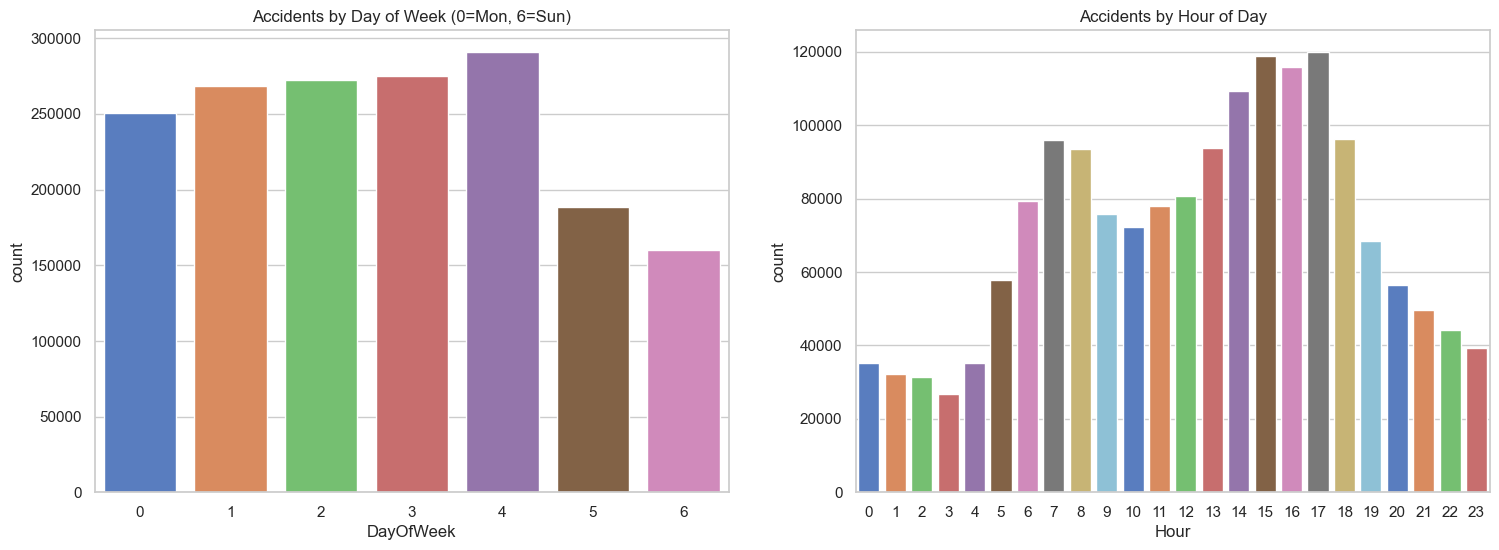

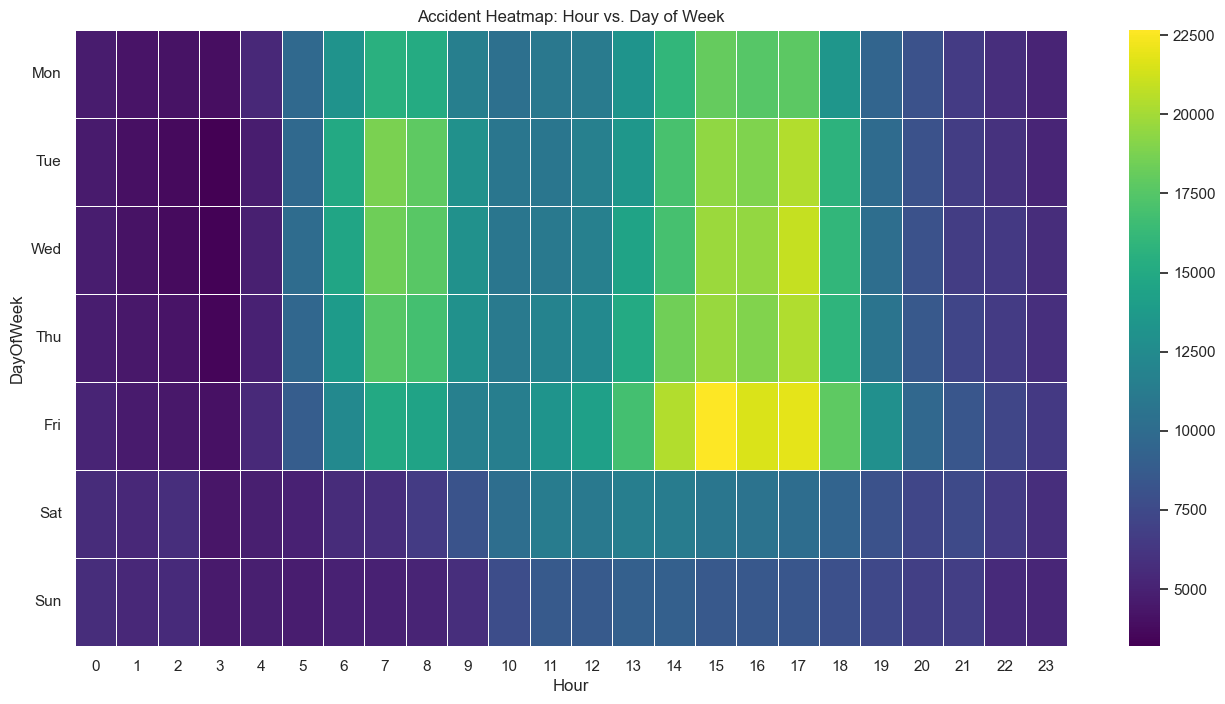

C:\Users\marga\AppData\Local\Temp\ipykernel_44960\3407072631.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




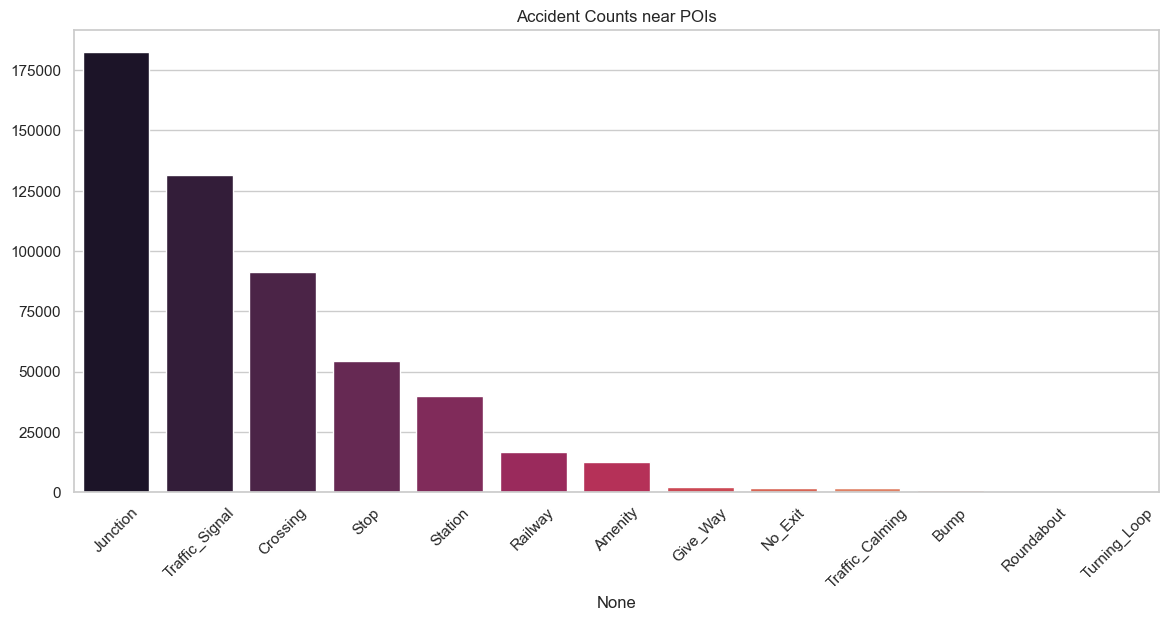

C:\Users\marga\AppData\Local\Temp\ipykernel_44960\3407072631.py:36: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\marga\AppData\Local\Temp\ipykernel_44960\3407072631.py:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




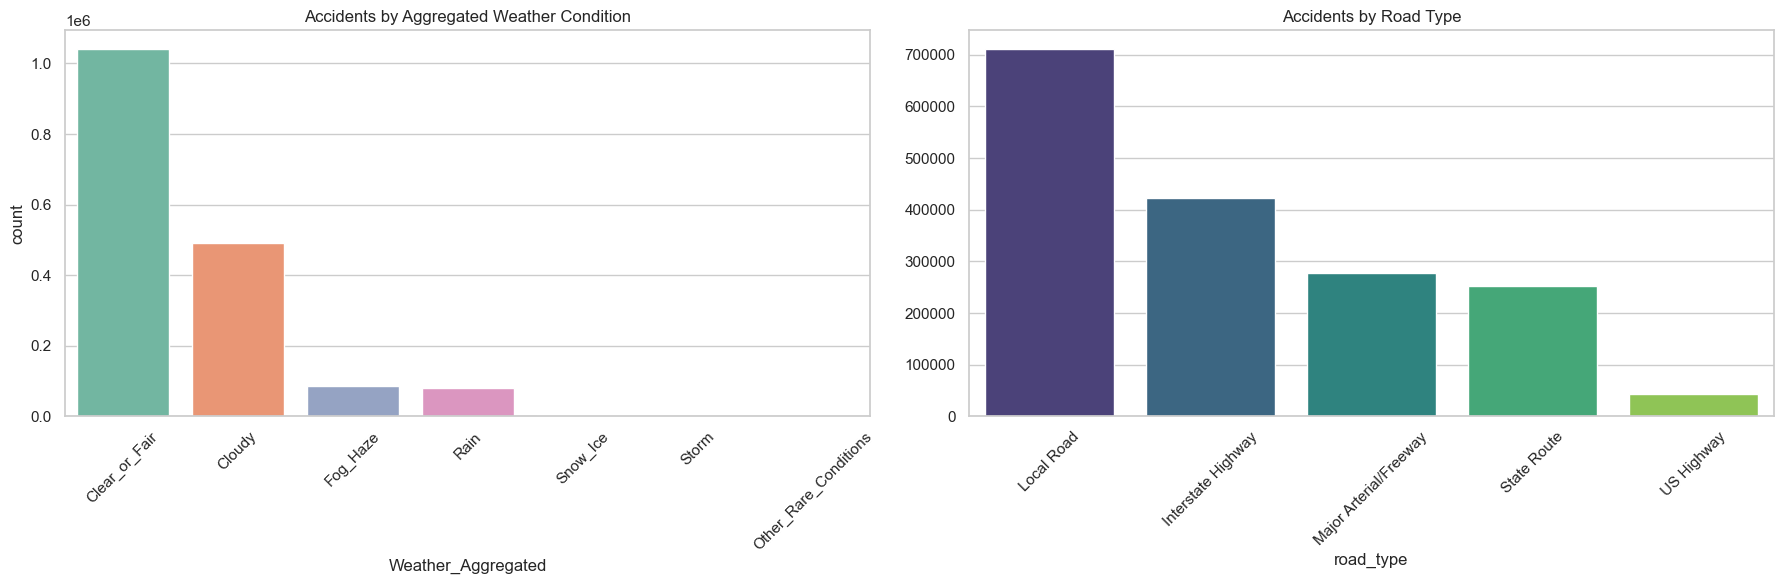

In [23]:
# Temporal Patterns: Day of Week and Hour
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(x='DayOfWeek', data=df, ax=axes[0], palette='muted')
axes[0].set_title('Accidents by Day of Week (0=Mon, 6=Sun)')

sns.countplot(x='Hour', data=df, ax=axes[1], palette='muted')
axes[1].set_title('Accidents by Hour of Day')
plt.show()

# Temporal Heatmap
df_heatmap = df.groupby(['DayOfWeek', 'Hour']).size().unstack(fill_value=0)
plt.figure(figsize=(16, 8))
sns.heatmap(df_heatmap, cmap="viridis", linewidths=.5)
plt.title('Accident Heatmap: Hour vs. Day of Week')
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.show()

# POI Analysis (Zoptymalizowane)
poi_columns = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 
               'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 
               'Traffic_Signal', 'Turning_Loop']

poi_counts = df[poi_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=poi_counts.index, y=poi_counts.values, palette='rocket')
plt.title('Accident Counts near POIs')
plt.xticks(rotation=45)
plt.show()

# Weather and Road Type
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(x='Weather_Aggregated', data=df, order=df['Weather_Aggregated'].value_counts().index, palette='Set2', ax=axes[0])
axes[0].set_title('Accidents by Aggregated Weather Condition')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=df['road_type'].value_counts().index, y=df['road_type'].value_counts().values, palette='viridis', ax=axes[1])
axes[1].set_title('Accidents by Road Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


C:\Users\marga\AppData\Local\Temp\ipykernel_44960\2034396490.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




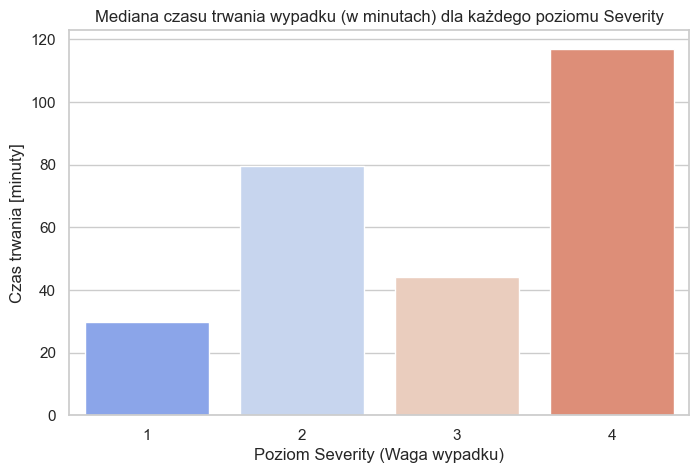

In [26]:
# Calculating the median and regressing the logarithm
median_dur = np.expm1(df.groupby('Severity')['Duration_log'].median()).reset_index()
median_dur.columns = ['Severity', 'Median_Duration_Minutes']

plt.figure(figsize=(8, 5))
sns.barplot(x='Severity', y='Median_Duration_Minutes', data=median_dur, palette='coolwarm')

plt.title('Mediana czasu trwania wypadku (w minutach) dla każdego poziomu Severity')
plt.ylabel('Czas trwania [minuty]')
plt.xlabel('Poziom Severity (Waga wypadku)')
plt.show()

In [27]:
df.columns.tolist()

['Severity',
 'Start_Time',
 'End_Time',
 'Start_Lat',
 'Start_Lng',
 'Street',
 'City',
 'County',
 'Zipcode',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temperature(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Speed(mph)',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way',
 'Junction',
 'No_Exit',
 'Railway',
 'Roundabout',
 'Station',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Turning_Loop',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight',
 'Hour',
 'DayOfWeek',
 'Month',
 'Year',
 'is_point_event',
 'Distance_log',
 'Duration_log',
 'Weather_Aggregated',
 'Wind_Direction_Mapped',
 'road_type',
 'Is_Daylight']

In [22]:
df.shape

(1705412, 48)

In [28]:
# Drop redundant columns and original features that were transformed
cols_to_drop = [
    'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 
    'Distance(mi)', 'Duration(min)', 'Weather_Condition'
]

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

In [29]:
# Use the existing 'Year' column since 'Start_Time' is no longer in the DataFrame
yearly_severity = df.groupby(['Year', 'Severity']).size().unstack(fill_value=0)

# Reset index and remove the axis name for a cleaner table display
yearly_severity = yearly_severity.reset_index()
yearly_severity.columns.name = None 

display(yearly_severity)

,Year,1,2,3,4
0,2016,98,86098,51546,1190
1,2017,85,92142,57049,1577
2,2018,39,95443,57405,1568
3,2019,18,165817,42121,1945
4,2020,5462,244923,25264,2417
5,2021,17,311479,22008,1236
6,2022,4358,346977,12090,2547
7,2023,0,72270,0,223


County
Los Angeles       510863
San Bernardino    107531
Orange            106953
San Diego         103044
Alameda            97572
Sacramento         95114
Riverside          86987
Santa Clara        67302
Contra Costa       51109
Kern               36984
Name: count, dtype: int64


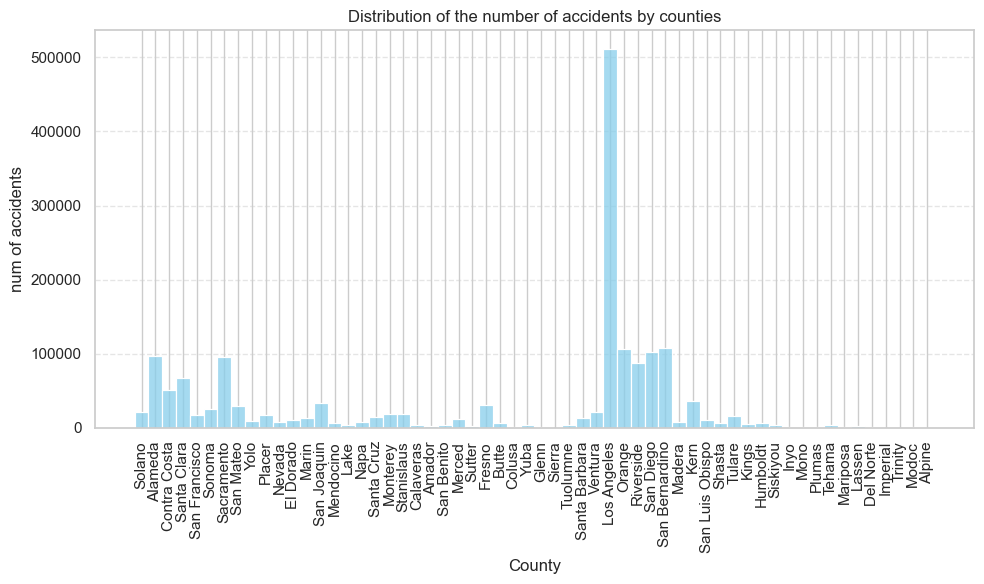

In [30]:
cases_by_county = df['County'].value_counts()
print(cases_by_county.head(10))

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='County', bins=len(df['County'].unique()), stat='count', color='skyblue')
plt.title('Distribution of the number of accidents by counties')
plt.xlabel('County')
plt.ylabel('num of accidents')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [31]:
df.shape

(1705412, 41)

In [ ]:
df.to_csv('CA_cleaned.csv', index=False)